In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

In [2]:
# Cell 1 — Load & Inspect Q20 Datasets

q20 = pd.read_csv(os.path.join(OUTPUT_PATH, "q20_catastrophic_exp.csv"))
q20_ur = pd.read_csv(os.path.join(OUTPUT_PATH, "q20_catastrophic_exp_ur.csv"))

print(q20.shape, q20.dtypes)
print(q20_ur.shape, q20_ur.dtypes)
print(q20_ur["dim1"].unique())

q20.head()

(711, 3) country          str
year           int64
catex_pct    float64
dtype: object
(1182, 4) country          str
year           int64
dim1             str
catex_pct    float64
dtype: object
<StringArray>
['Urban', 'Rural']
Length: 2, dtype: str


,country,year,catex_pct
0,Afghanistan,2013,14.63
1,Afghanistan,2007,4.84
2,Albania,2012,16.72
3,Albania,2008,13.91
4,Albania,2005,19.51


In [3]:
# Cell 2 — Reporting Coverage Per Year (flag sparse years before trusting the global trend)

coverage = q20.groupby("year")["country"].nunique().reset_index(name="n_countries")
coverage

,year,n_countries
0,1985,2
1,1986,2
2,1987,1
3,1988,1
4,1990,2
5,1991,3
6,1992,3
7,1993,6
8,1994,5
9,1995,12


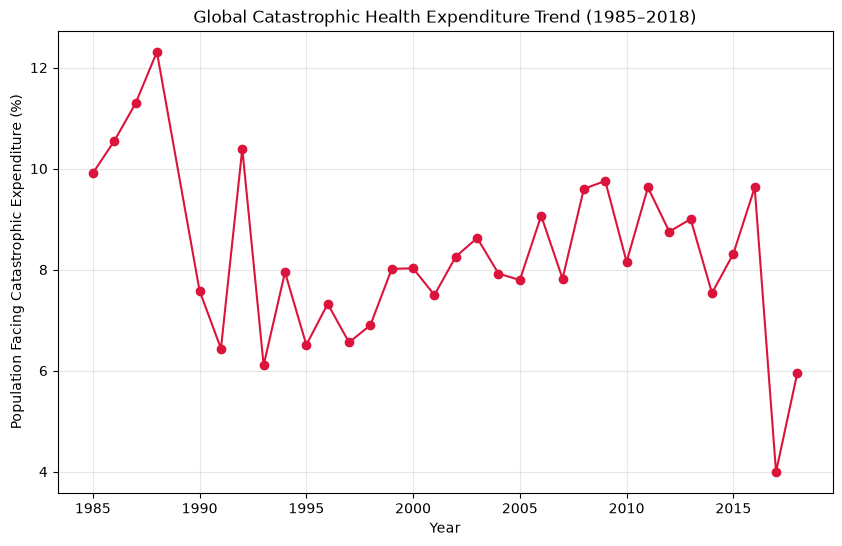

In [4]:
# Cell 3 — Global Trend: Catastrophic Health Expenditure (1985–2018)

global_catex = q20.groupby("year")["catex_pct"].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(global_catex["year"], global_catex["catex_pct"], marker="o", color="crimson")
plt.xlabel("Year")
plt.ylabel("Population Facing Catastrophic Expenditure (%)")
plt.title("Global Catastrophic Health Expenditure Trend (1985–2018)")
plt.grid(alpha=0.3)
plt.show()

In [5]:
# Cell 4 — Latest-Year-Per-Country Snapshot (for ranking, since reporting years vary)

catex_latest = (
    q20.sort_values("year", ascending=False)
    .drop_duplicates(subset="country", keep="first")
    .reset_index(drop=True)
)

print(catex_latest["year"].describe())
catex_latest.head()

count     153.00000
mean     2010.96732
std         4.82376
min      1993.00000
25%      2009.00000
50%      2012.00000
75%      2015.00000
max      2018.00000
Name: year, dtype: float64


,country,year,catex_pct
0,Indonesia,2018,2.71
1,Peru,2018,9.21
2,Thailand,2017,2.22
3,Bhutan,2017,1.79
4,Viet Nam,2016,9.39


In [6]:
# Cell 5 — Top 10 Highest and Lowest Countries (Latest Available Year)

top10_highest = catex_latest.sort_values("catex_pct", ascending=False).head(10)
top10_lowest = catex_latest.sort_values("catex_pct").head(10)

print("Highest:")
print(top10_highest[["country", "year", "catex_pct"]])

print("\nLowest:")
print(top10_lowest[["country", "year", "catex_pct"]])

Highest:
               country  year  catex_pct
81        Sierra Leone  2011      54.20
146            Lebanon  1999      44.85
58             Georgia  2013      29.21
71               Egypt  2012      26.20
124             Brazil  2008      25.56
7           Bangladesh  2016      24.67
133            Morocco  2006      22.00
29   Republic of Korea  2015      21.78
62               China  2013      19.72
138        Switzerland  2004      19.70

Lowest:
      country  year  catex_pct
30     Gambia  2015       0.20
95     Zambia  2010       0.29
148      Oman  1999       0.63
123      Fiji  2008       0.78
116  Botswana  2009       1.00
74      Ghana  2012       1.11
143  Djibouti  2002       1.14
137  Honduras  2004       1.14
19     Rwanda  2016       1.15
118   Namibia  2009       1.22


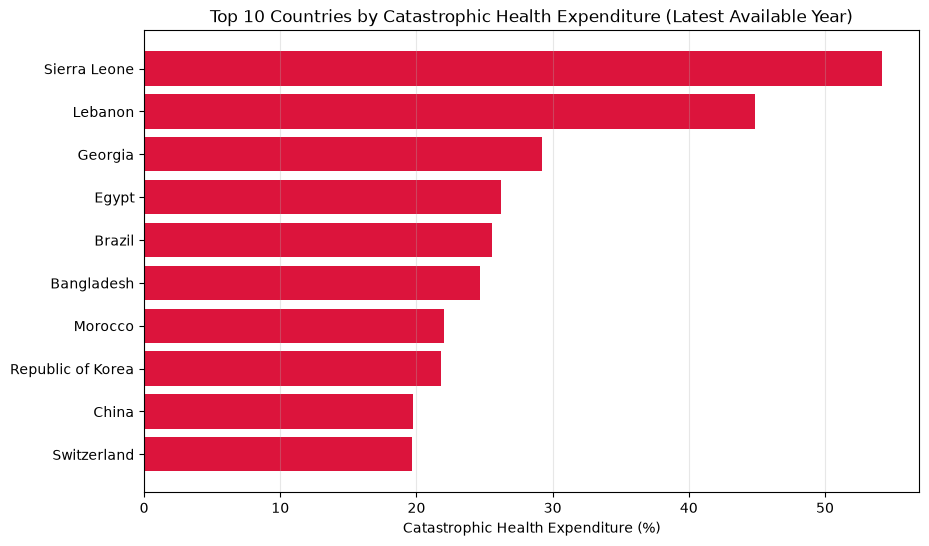

In [7]:
# Cell 6 — Plot Top 10 Highest Countries

plt.figure(figsize=(10, 6))
plt.barh(top10_highest["country"], top10_highest["catex_pct"], color="crimson")
plt.xlabel("Catastrophic Health Expenditure (%)")
plt.title("Top 10 Countries by Catastrophic Health Expenditure (Latest Available Year)")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

In [8]:
# Cell 7 — Per-Country Rate of Change (First vs Last Available Year)

def first_last_change(group):
    group = group.sort_values("year")
    first, last = group.iloc[0], group.iloc[-1]
    years_elapsed = last["year"] - first["year"]
    return pd.Series({
        "first_year": first["year"], "first_value": first["catex_pct"],
        "last_year": last["year"], "last_value": last["catex_pct"],
        "years_elapsed": years_elapsed,
        "total_change": last["catex_pct"] - first["catex_pct"],
    })

country_change = q20.groupby("country").apply(first_last_change).reset_index()
country_change = country_change[country_change["years_elapsed"] > 0]
country_change["annual_change"] = country_change["total_change"] / country_change["years_elapsed"]

country_change.head()

,country,first_year,first_value,last_year,last_value,years_elapsed,total_change,annual_change
0,Afghanistan,2007.0,4.84,2013.0,14.63,6.0,9.79,1.631667
1,Albania,1996.0,7.39,2012.0,16.72,16.0,9.33,0.583125
3,Argentina,1996.0,9.70,2004.0,16.90,8.0,7.20,0.900000
4,Armenia,1999.0,15.35,2013.0,16.05,14.0,0.70,0.050000
7,Azerbaijan,2002.0,6.97,2005.0,8.12,3.0,1.15,0.383333


In [9]:
# Cell 8 — Fastest Increasing and Fastest Decreasing Countries

fastest_increasing = country_change.sort_values("annual_change", ascending=False).head(10)
fastest_decreasing = country_change.sort_values("annual_change").head(10)

print("Fastest increasing:")
print(fastest_increasing[["country", "first_year", "first_value", "last_year", "last_value", "annual_change"]])

print("\nFastest decreasing:")
print(fastest_decreasing[["country", "first_year", "first_value", "last_year", "last_value", "annual_change"]])

Fastest increasing:
          country  first_year  first_value  last_year  last_value  \
121  Sierra Leone      2003.0        10.42     2011.0       54.20   
95        Morocco      1998.0         4.15     2006.0       22.00   
61          Haiti      2012.0         9.43     2013.0       11.54   
0     Afghanistan      2007.0         4.84     2013.0       14.63   
53        Georgia      1997.0         8.00     2013.0       29.21   
43          Egypt      1997.0         7.64     2012.0       26.20   
3       Argentina      1996.0         9.70     2004.0       16.90   
45        Estonia      1995.0         3.01     2007.0       12.76   
29          China      1995.0         5.78     2013.0       19.72   
19       Bulgaria      1995.0         2.09     2010.0       12.84   

     annual_change  
121       5.472500  
95        2.231250  
61        2.110000  
0         1.631667  
53        1.325625  
43        1.237333  
3         0.900000  
45        0.812500  
29        0.774444  
19        

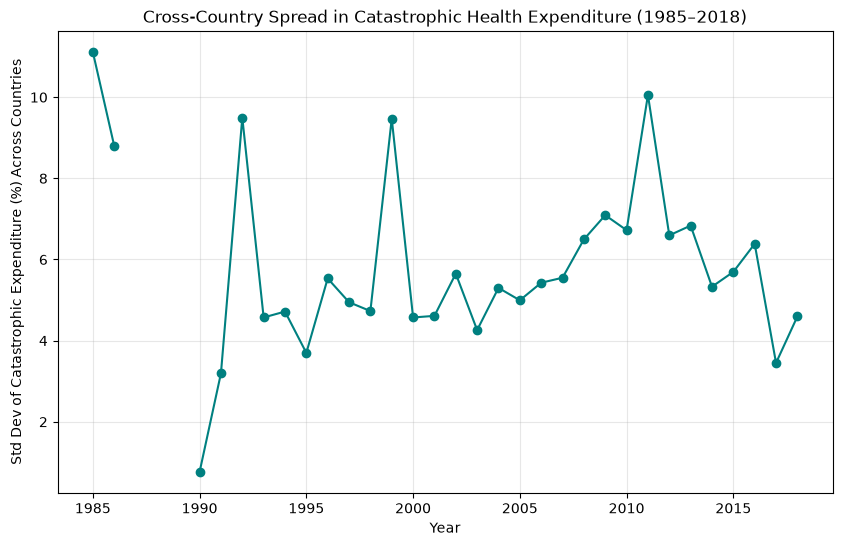

In [10]:
# Cell 9 — Convergence or Divergence? Cross-Country Spread Over Time

spread = q20.groupby("year")["catex_pct"].std().reset_index(name="std_catex")

plt.figure(figsize=(10, 6))
plt.plot(spread["year"], spread["std_catex"], marker="o", color="teal")
plt.xlabel("Year")
plt.ylabel("Std Dev of Catastrophic Expenditure (%) Across Countries")
plt.title("Cross-Country Spread in Catastrophic Health Expenditure (1985–2018)")
plt.grid(alpha=0.3)
plt.show()

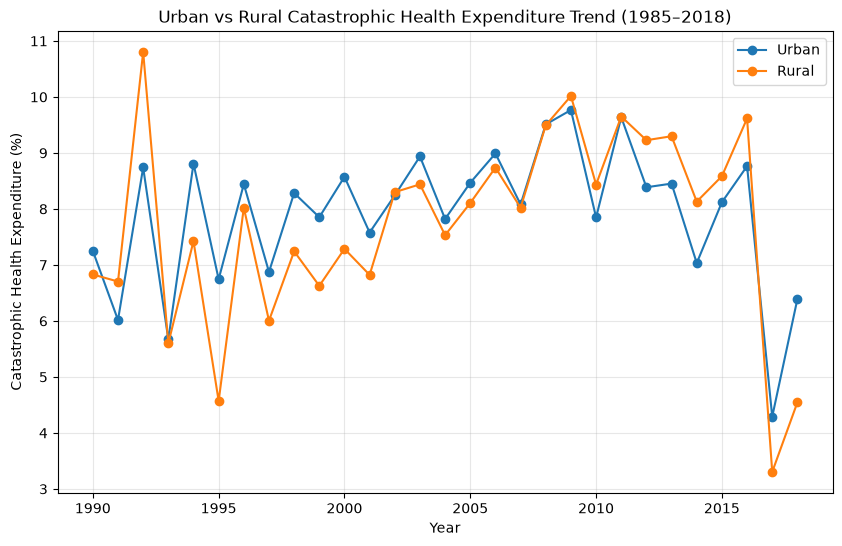

In [11]:
# Cell 10 — Urban vs Rural Trend Over Time

ur_trend = q20_ur.groupby(["year", "dim1"])["catex_pct"].mean().reset_index()

plt.figure(figsize=(10, 6))
for dim in ["Urban", "Rural"]:
    subset = ur_trend[ur_trend["dim1"] == dim]
    plt.plot(subset["year"], subset["catex_pct"], marker="o", label=dim)

plt.xlabel("Year")
plt.ylabel("Catastrophic Health Expenditure (%)")
plt.title("Urban vs Rural Catastrophic Health Expenditure Trend (1985–2018)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()